In [1]:
# 0. Link colab với Drive
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive

Mounted at /content/drive
/content/drive/MyDrive


In [3]:
# clone YOLOv5 repository
!git clone https://github.com/ultralytics/yolov5  # clone repo
%cd yolov5
!git reset --hard fbe67e465375231474a2ad80a4389efc77ecff99

fatal: destination path 'yolov5' already exists and is not an empty directory.
/content/drive/MyDrive/yolov5
Updating files: 100% (111/111), done.
HEAD is now at fbe67e46 Fix `OMP_NUM_THREADS=1` for macOS (#8624)


In [4]:
# install dependencies as necessary
!pip install -qr requirements.txt  # install dependencies (ignore errors)
import torch

from IPython.display import Image, clear_output  # to display images
from utils.downloads import attempt_download  # to download models/datasets

# clear_output()
print('Setup complete. Using torch %s %s' % (torch.__version__, torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 407.8/407.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.10 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 4.21.2 which is incompatible.
google-api-core 2.19.2 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0.dev0,>=3.19.5, but you have protobuf 4.21.2 which is incompatible.
google-cloud-aiplatform 1.73.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 4.21.2 which is incompatible.
google-cloud-bigquery-connection 1.16.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.

In [5]:
import torch
from drive.MyDrive.yolov5 import utils
display = utils.notebook_init()  # checks

INFO:yolov5:YOLOv5 🚀 v6.1-306-gfbe67e46 Python-3.10.12 torch-2.5.1+cu121 CPU
YOLOv5 🚀 v6.1-306-gfbe67e46 Python-3.10.12 torch-2.5.1+cu121 CPU


Setup complete ✅ (2 CPUs, 12.7 GB RAM, 32.7/107.7 GB disk)


In [ ]:
!unzip -q ../data.zip -d ../


In [ ]:
!pip install wandb

In [ ]:
# Train YOLOv5
!python /content/drive/MyDrive/yolov5/train.py --img 640 --batch 16 --epochs 50 --data custom_data.yaml --weights yolov5s.pt

Streaming output truncated to the last 5000 lines.
     41/49     4.41G   0.01814  0.009584   0.01791        35       640:  72% 215/297 [02:07<00:56,  1.46it/s]/content/drive/MyDrive/yolov5/train.py:326: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
     41/49     4.41G   0.01811  0.009575   0.01785        33       640:  73% 216/297 [02:07<00:51,  1.57it/s]/content/drive/MyDrive/yolov5/train.py:326: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
     41/49     4.41G   0.01809  0.009567   0.01784        31       640:  73% 217/297 [02:09<01:01,  1.30it/s]/content/drive/MyDrive/yolov5/train.py:326: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
     41/49

KIỂM THỬ TRÊN TẬP TEST

In [ ]:
!python detect.py --weights /content/drive/MyDrive/yolov5/runs/train/exp2/weights/best.pt --img 416 --conf 0.4 --source /content/drive/MyDrive/test/images



detect: weights=['/content/drive/MyDrive/yolov5/runs/train/exp2/weights/best.pt'], source=/content/drive/MyDrive/test/images, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
YOLOv5 🚀 v6.1-306-gfbe67e46 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)

/content/drive/MyDrive/yolov5/models/experimental.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). I

Hiển thị kết quả

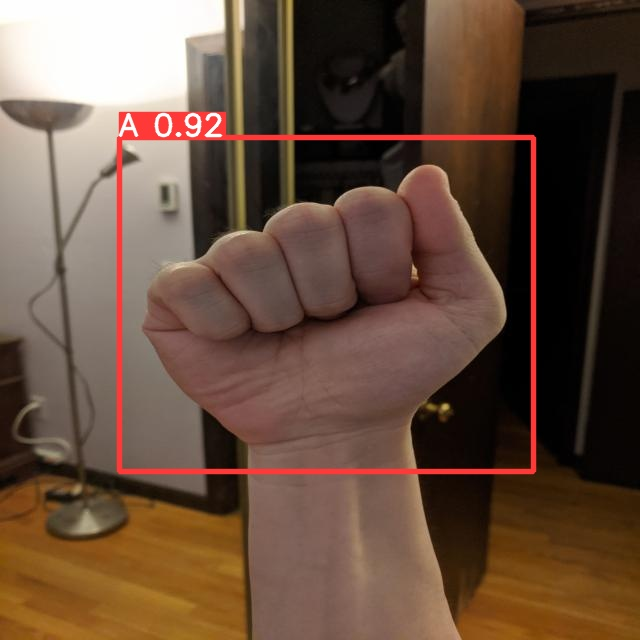

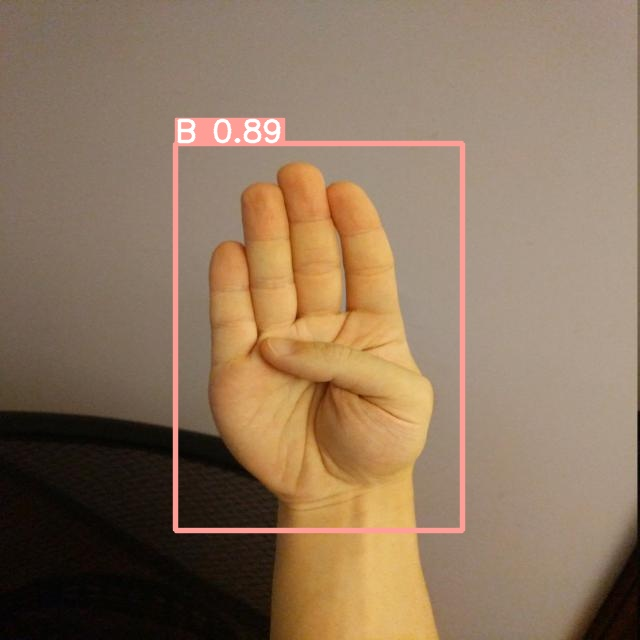

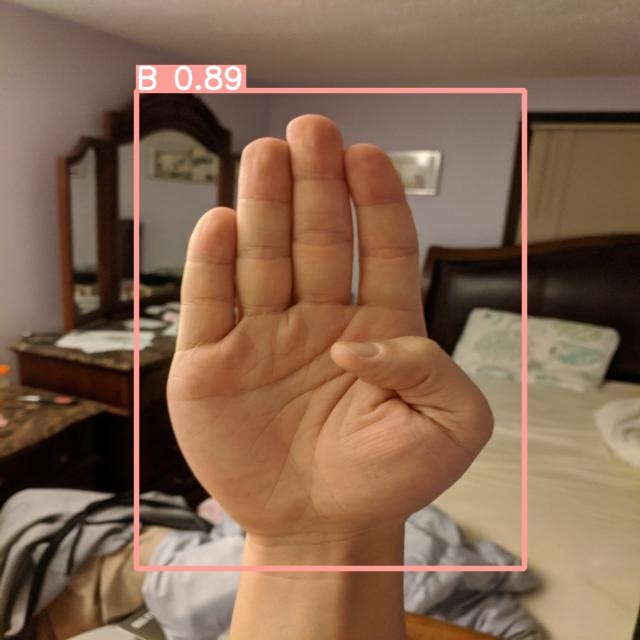

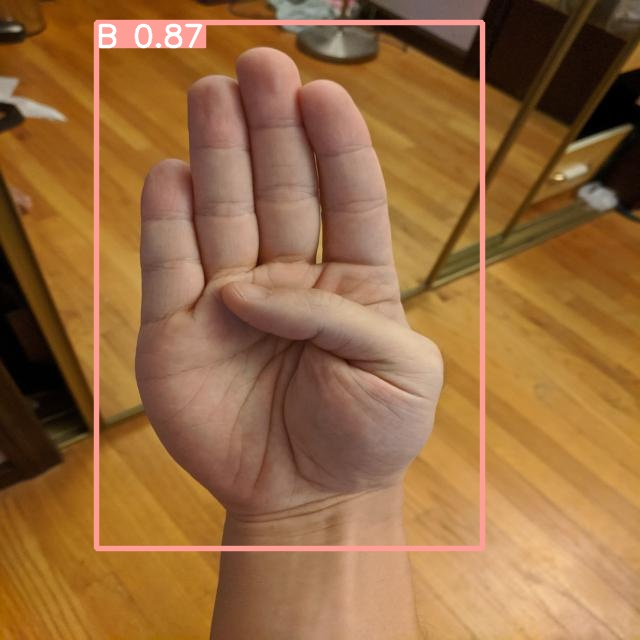

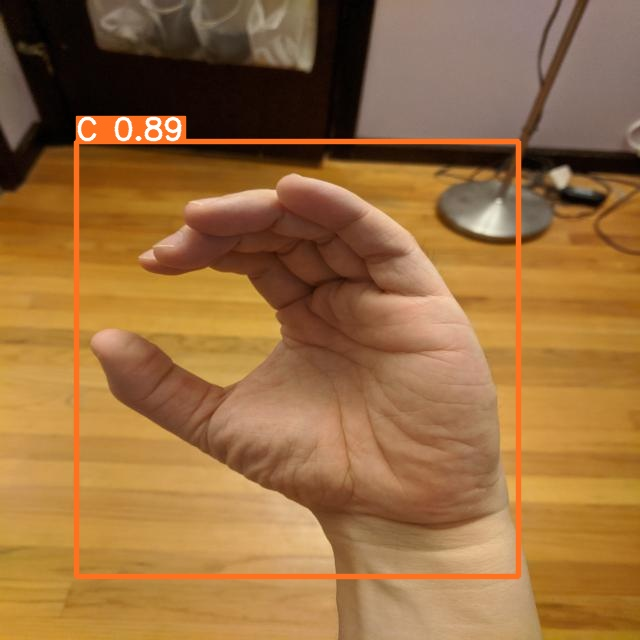

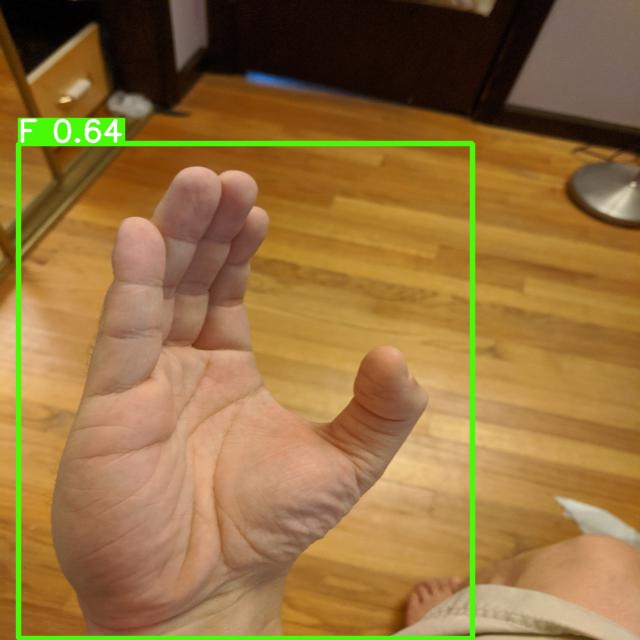

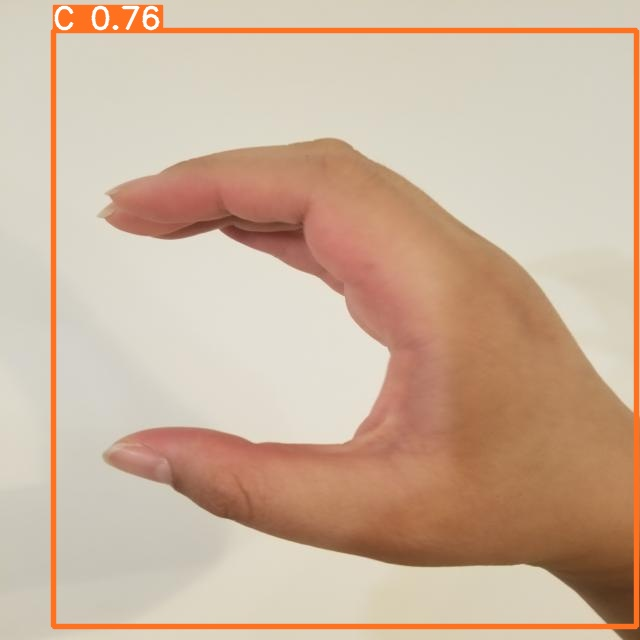

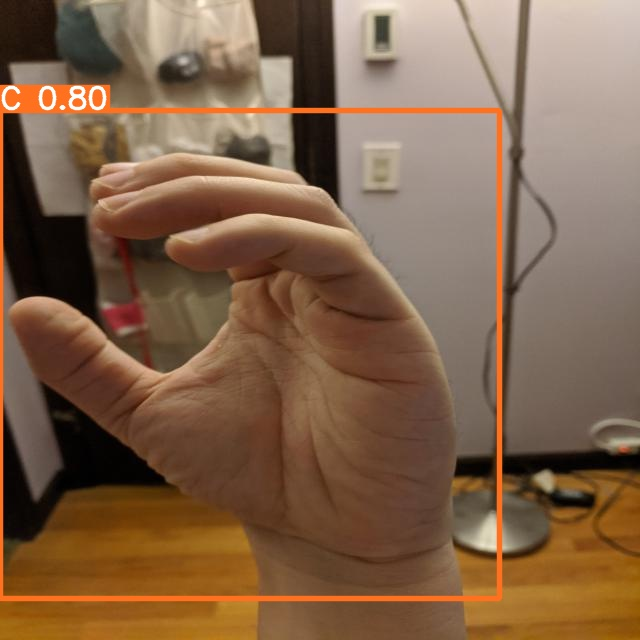

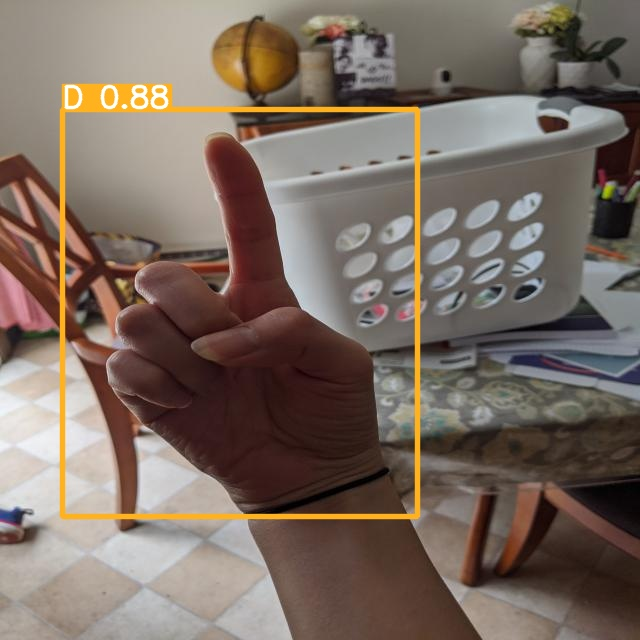

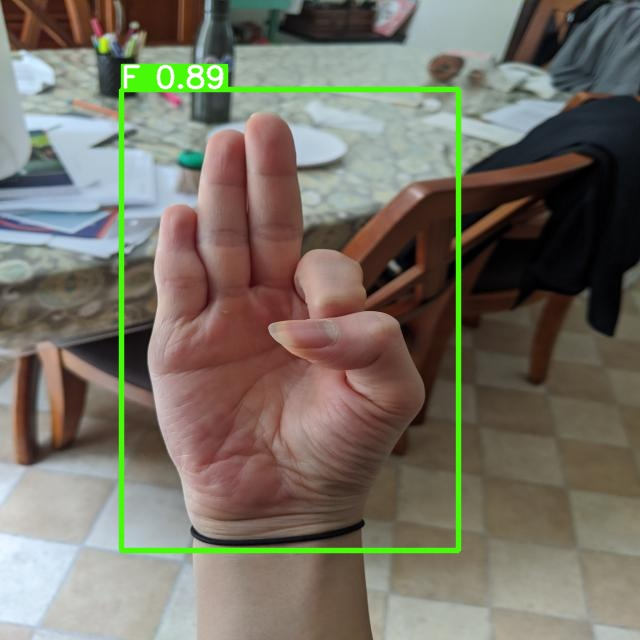

In [16]:
import glob
from IPython.display import display, Image

# Lấy danh sách các file ảnh trong thư mục
result_images = glob.glob('runs/detect/exp2/*.jpg')

# Hiển thị 10 ảnh đầu tiên
for img_path in result_images[:5]:  # Lấy 10 ảnh đầu tiên
    display(Image(filename=img_path, width=300))

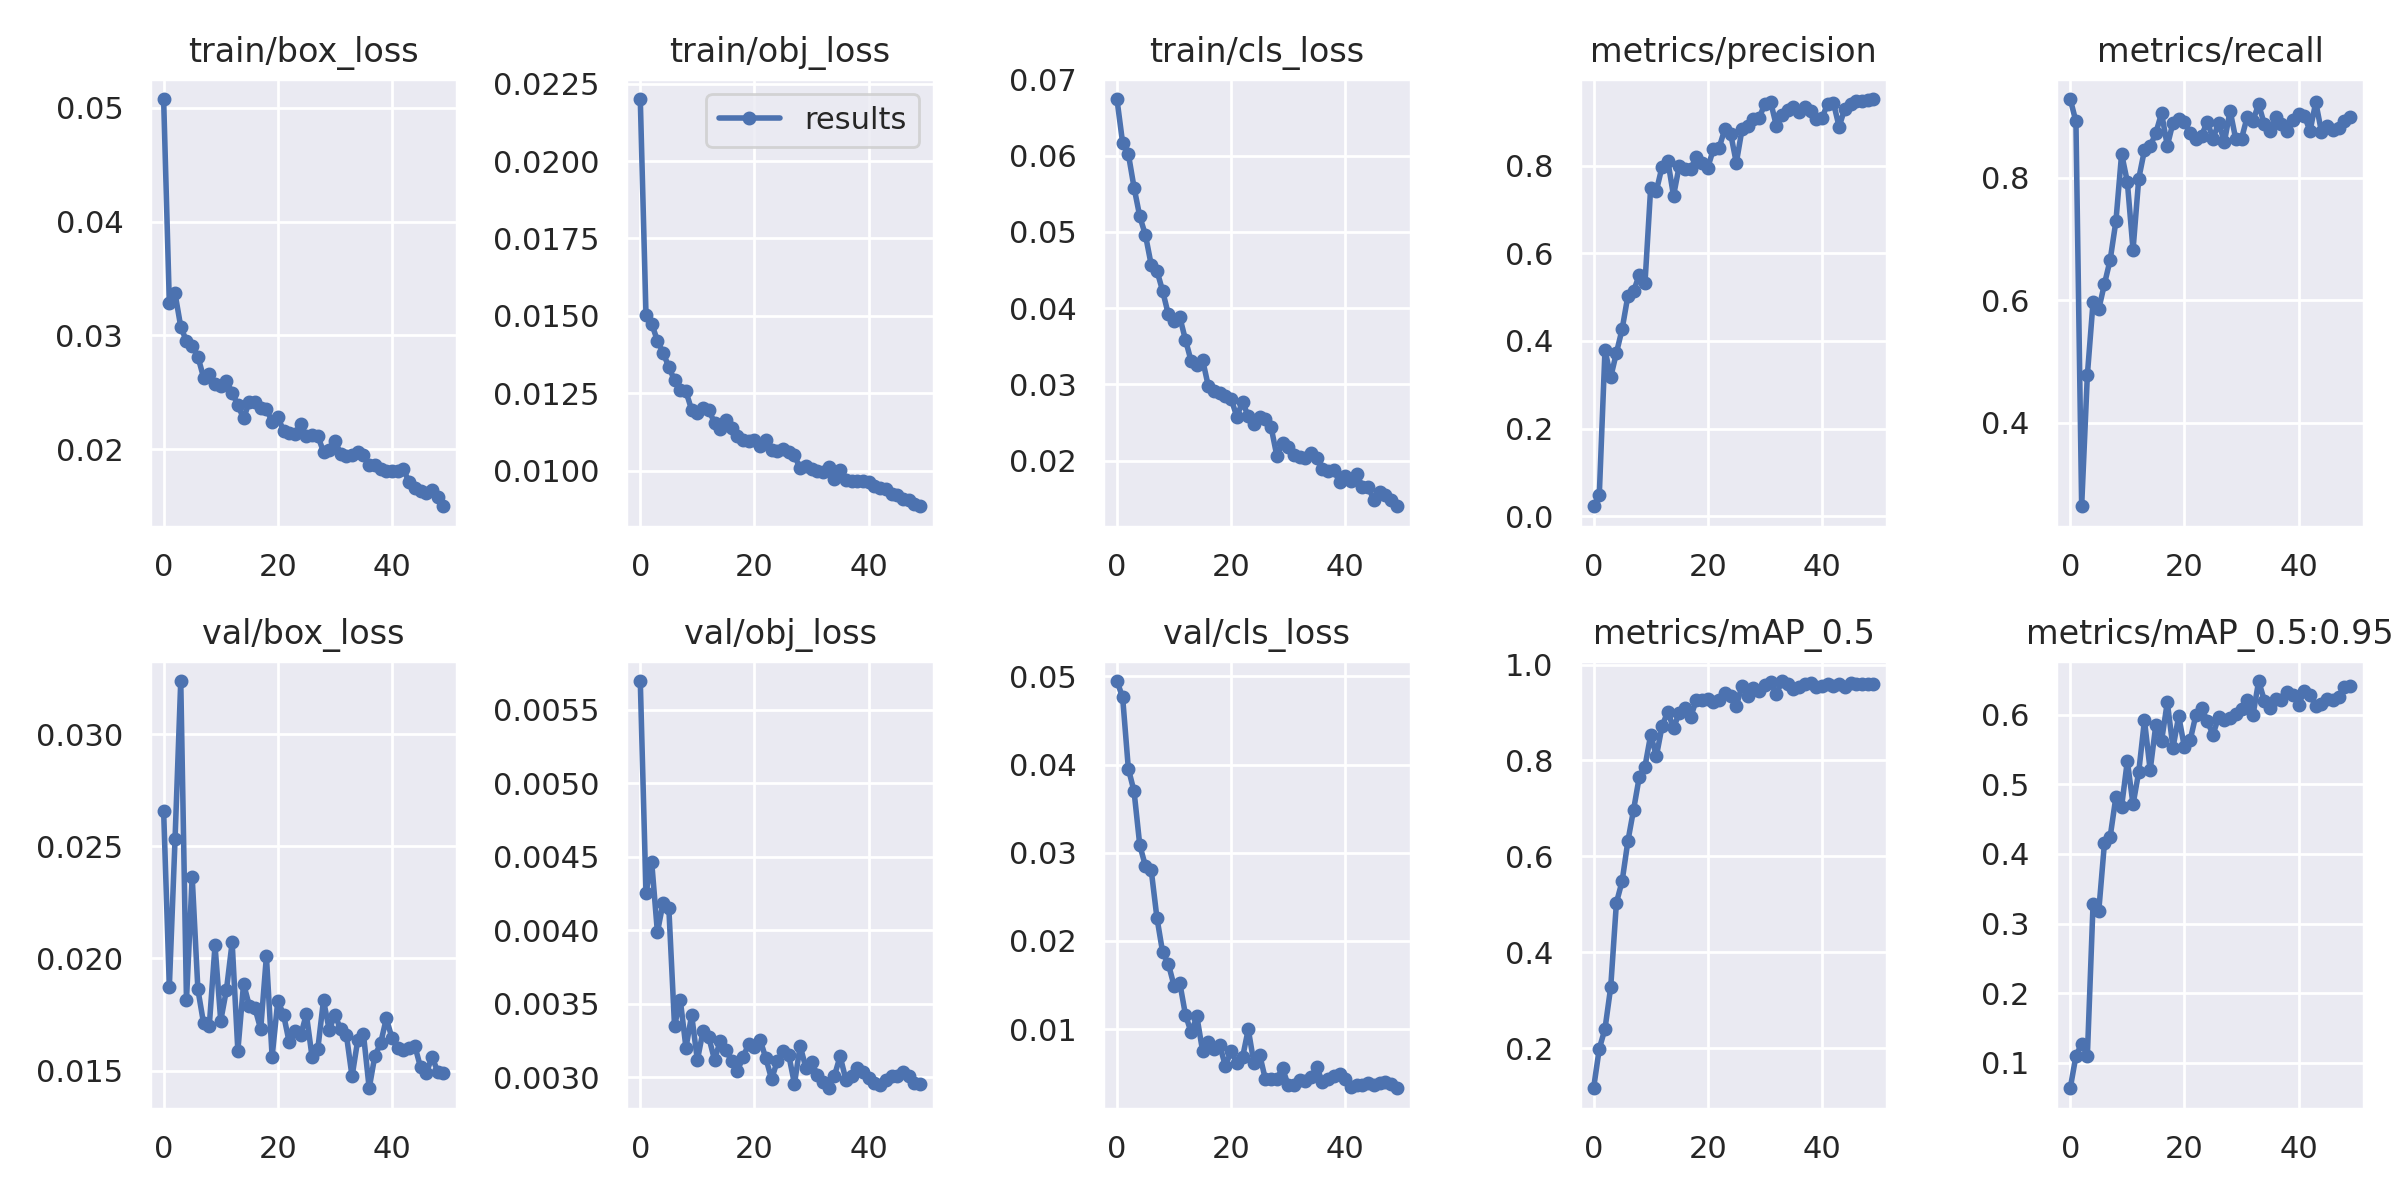

In [20]:
result = '/content/drive/MyDrive/yolov5/runs/train/exp2/results.png'
display(Image(filename=result))